# A nonsymmetric system: convection-diffusion with LGMRES

We solve the convection-diffusion problem known as *double glazing* (Elman, Silvester and Wathen, *Finite Elements and Fast Iterative Solvers*),

$$-\varepsilon\,\Delta u + \mathbf b\cdot\nabla u = 0 \quad \text{in } \Omega = (-1, 1)^2, \qquad \mathbf b(x, y) = \left(2y\,(1 - x^2),\ -2x\,(1 - y^2)\right),$$

with $u = 1 - x^4$ on the top wall $y = 1$, the hot wall, and $u = 0$ on the other three. The wind $\mathbf b$ is a recirculating flow that turns clockwise around the center, and $\varepsilon = 0.005$ is small, so heat is carried around the cavity by the flow far more than it diffuses. The solution has thin boundary layers and a large region where it is nearly constant.

Multiplying by a test function $v$ that vanishes on the boundary and integrating by parts gives

$$a(u, v) = \varepsilon \int_\Omega \nabla u\cdot\nabla v\,dx + \int_\Omega (\mathbf b\cdot\nabla u)\,v\,dx = 0.$$

The first term is symmetric in $u$ and $v$. The second is not. Since $\nabla\cdot\mathbf b = 0$ and $u v = 0$ on the boundary,

$$\int_\Omega (\mathbf b\cdot\nabla u)\,v\,dx = -\int_\Omega (\mathbf b\cdot\nabla v)\,u\,dx,$$

so the convection matrix $C$ is skew-symmetric, $C^T = -C$, and the matrix $A = \varepsilon K + C$ is nonsymmetric. Conjugate gradients does not apply, and the Krylov method of choice is GMRES or one of its variants.

In [1]:
import time
import numpy as np
import scipy.sparse.linalg as sla
import matplotlib.pyplot as plt
import femd as fd
from femd import dot, grad, dx

An unstructured mesh of the square and continuous $P_1$ elements. The whole boundary has the marker 1, and `dirichlet={1: g}` builds the data $g = 1 - x^4$ on the top wall and $0$ elsewhere into the space.

In [2]:
eps = 0.005
m = fd.triangulate([(-1, -1), (1, -1), (1, 1), (-1, 1)], max_edge=0.015, min_angle=28)

def g(x, y):
    return np.where(y > 1 - 1e-12, 1 - x**4, 0.0)

V = fd.LagrangeSpace(m, 1, dirichlet={1: g})
u, v = fd.TrialFunction(V), fd.TestFunction(V)
x, y = fd.x, fd.y
b_wind = fd.as_vector([2 * y * (1 - x**2), -2 * x * (1 - y**2)])
print(m.ntriangles, "triangles,", V.dim, "unknowns")

90964 triangles, 44971 unknowns


**The matrix.** We assemble the diffusion and convection parts separately to see their symmetry, and add them. The right-hand side comes from the lift $u_g$ of the boundary data, $b = -A\,u_g$ restricted to the free unknowns ([manual, Section 4.1](../docs/manual.md#41-lifting-step-by-step)).

In [3]:
K = fd.form(dot(grad(u), grad(v)) * dx).assemble()
Cm = fd.form(dot(b_wind, grad(u)) * v * dx).assemble()
A = eps * K + Cm

S = Cm.tocsr()
print("K symmetric:", K.is_symmetric(), "  A symmetric:", A.is_symmetric())
print("||C + C^T|| / ||C|| =", sla.norm(S + S.T) / sla.norm(S))

a = (eps * dot(grad(u), grad(v)) + dot(b_wind, grad(u)) * v) * dx
ug = V.lift()                                   # the boundary data, a Function of V.unconstrained
rhs = -fd.form(a).action(ug).assemble()         # -a(u_g, v)

K symmetric: True   A symmetric: False
||C + C^T|| / ||C|| = 3.3267492358641405e-16


**A direct solve as reference.** For a nonsymmetric matrix `A.solver()` takes SciPy's sparse LU (SuperLU).

In [4]:
t0 = time.perf_counter()
u_direct = A.solver().solve(rhs, lift=ug)       # a Function of V.unconstrained, data included
print(f"sparse LU: {time.perf_counter() - t0:.2f} s")

sparse LU: 0.20 s


**LGMRES.** GMRES($m$) builds an orthonormal basis of the Krylov space and restarts after $m$ steps to bound the memory and the work of the orthogonalization. At each restart it forgets everything it has learned, and for a convection-dominated problem it can stagnate: the residual stops decreasing.

LGMRES($m$, $k$) (Baker, Jessup and Manteuffel, 2005) keeps the corrections of the last $k$ cycles, approximations of the error, and adds them to the next Krylov space. That small memory of the earlier cycles is often enough to overcome the stagnation. FEMd's `fd.lgmres` has $m = 20$ and $k = 2$ by default.

Both methods are left-preconditioned here by ILU(0), the incomplete LU factorization with the sparsity pattern of $A$, computed on the reverse Cuthill-McKee order (see `example8`). The tolerance `tol` bounds the preconditioned relative residual $\lVert M^{-1}(b - Ax)\rVert / \lVert M^{-1}b\rVert$, and `info.residual` is the true one, $\lVert b - Ax\rVert / \lVert b\rVert$.

In [5]:
P = A.preconditioner("ilu0")

t0 = time.perf_counter()
xk, info = fd.lgmres(A, rhs, M=P, restart=20, maxiter=4000)
print(f"{time.perf_counter() - t0:.2f} s,", info)

u_lgmres = fd.Function(V.unconstrained, "u", V.prolongate(xk.vector) + ug.vector)   # add the boundary data
print("max |LGMRES - LU| =", np.max(np.abs(u_lgmres.vector - u_direct.vector)))

1.98 s, KrylovInfo(lgmres converged in 2647 iterations, residual 3.01e-11, preconditioned 9.97e-11)
max |LGMRES - LU| = 6.782675088246037e-09


**GMRES against LGMRES.** The same system with three restart lengths, each allowed 4000 iterations.

In [6]:
print("method    restart   iterations   converged   true residual    time")
for restart in (10, 20, 40):
    for name, method in (("GMRES", fd.gmres), ("LGMRES", fd.lgmres)):
        t0 = time.perf_counter()
        xx, info = method(A, rhs, M=P, restart=restart, maxiter=4000, warn=False)
        t = time.perf_counter() - t0
        print(f"{name:8s} {restart:7d} {info.iterations:12d}   {str(info.converged):9s} {info.residual:13.1e} {t:8.2f} s")

method    restart   iterations   converged   true residual    time
GMRES         10         4000   False           5.7e-07     2.68 s
LGMRES        10         3944   True            2.9e-11     2.59 s
GMRES         20         4000   False           1.4e-07     2.93 s
LGMRES        20         2601   True            3.0e-11     1.93 s
GMRES         40         4000   False           2.6e-09     3.59 s


LGMRES        40         1731   True            3.1e-11     1.58 s


GMRES stagnates for every restart length. After 4000 iterations its residual is still far above the tolerance, and it decreases only slowly with $m$. LGMRES converges in each case, and the longer the restart, the fewer iterations it needs. Its iteration count includes the $k$ augmentation steps of each cycle.

Near stagnation an iteration is sensitive to rounding, so the counts can differ by a few percent between machines and thread counts. LGMRES with $m = 10$ converges close to the limit of 4000, and on another machine it may need a few more.

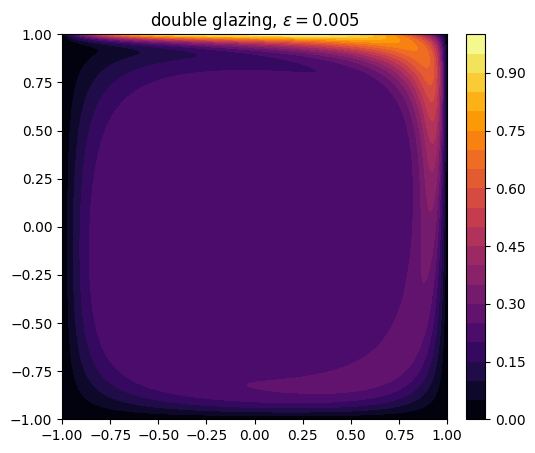

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
u_lgmres.plot(ax, contour=True, levels=20, cmap="inferno")
ax.set_title(r"double glazing, $\varepsilon = 0.005$")
ax.set_aspect("equal")
plt.show()

The contour lines follow the recirculating flow. Heat enters from the hot top wall, is swept around the cavity in a thin layer along the walls, and the interior settles to a nearly constant temperature.

**Direct or iterative?** On this mesh the sparse LU solves the system in a fraction of a second, faster than any of the iterations. That is typical of 2D problems of moderate size, where the fill of a sparse factorization stays small. Krylov methods pay off when the factorization becomes too expensive in time or memory, in 3D or on very fine meshes, and when only products $A x$ are available, as in the matrix-free Newton-Krylov methods of `fd.newton` and `fd.csnewton`. There a nonsymmetric Jacobian is the rule and LGMRES is the robust choice.